# Investigate Enhancer Single Cell Expression

From the previous analysis we have everything ready:

1. CBC (DNA) x cellBC Table
2. EBC (RNA) x cellBC Table
3. Annotated `adata` object

Now it's time to put things together and to quantitatively see where the enhancers are being expressed, on a single-cell level.

In [1]:
import scanpy as sc
import anndata as ad
import skimage
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Datasets

In [63]:
adata = sc.read_h5ad('../6-grammar_final/JCF-HT_annotated.h5ad')

In [64]:
# Drop the Unknown cells as they are not helpful
adata = adata[adata.obs['updated_label']!='Unknown']

In [65]:
adata

View of AnnData object with n_obs × n_vars = 16929 × 14950
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res3', 'celltype', 'updated_label', 'col_celltype', 'cellBC'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'KH', 'Unique name (used in some papers)', 'Human homolog', 'Gene Name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'dendrogram_leiden_res1', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res3', 'leiden_res3_colors', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'sample_colors', 'scrublet', 'umap', 'updated_label_colors'
    obsm: 'X_pca', 'X_umap'
    varm: '

In [66]:
df1 = adata.obs[adata.obs['sample']=='JCF-1']
df2 = adata.obs[adata.obs['sample']=='JCF-2']
df3 = adata.obs[adata.obs['sample']=='JCF-3']

In [67]:
ebc1 = pd.read_csv('../6-grammar_final/JCF-MPRA-1.csv', index_col = 0)
ebc2 = pd.read_csv('../6-grammar_final/JCF-MPRA-2.csv', index_col = 0)
ebc3 = pd.read_csv('../6-grammar_final/JCF-MPRA-3.csv', index_col = 0)

In [68]:
cbc1 = pd.read_csv('../6-grammar_final/JCF-CBC-1.csv', index_col = 0)
cbc2 = pd.read_csv('../6-grammar_final/JCF-CBC-2.csv', index_col = 0)
cbc3 = pd.read_csv('../6-grammar_final/JCF-CBC-3.csv', index_col = 0)

In [121]:
lookup = pd.read_csv("../6-grammar_final/refs/final_enhancer_ebc_cbc_lookup.csv")

In [122]:
lookup.head()

,enhancer_id,Enhancer variant name,Enhancer Sequence,ebc,cbc,bin-anno
0,ORL13,ORL13_1,TTTCGAAATTTCCTTCATCTGAAGCTCGAGATAACACGGAAGTTGC...,TAACGGCGTCTGACCGAGGGGGCGTAACAG,GCGCAGCGCCGCCAGTCATGAACCC,Moderate
1,ORL13,ORL13_2,TTTCGAAATTTCCTTCATCTGAAGCTCGAGATAACACGGAAGTTGC...,AGGGAGGTGGTGTATTGTCCGTTAGACTCG,CACGAGACAGCAGGACGACGCGACA,Moderate
2,ORL13,ORL13_3,TTTCGAAATTTCCTTCATCTGAAGCTCGAGATAACACGGAAGTTGC...,GTAGCCTACTATGAGCCGACAGGACACCAC,CGCTCAACCAACGAGTCACCAACAA,Moderate
3,ORL13,ORL13_4,TTTCGAAATTTCCTTCATCTGAAGCTCGAGATAACACGGAAGTTGC...,ACTCAGGTTCAGCCTTAGACTCGTCCGTGG,ATATATTCGCAACTCAAAGCGAAGC,Moderate
4,ORL13,ORL13_5,TTTCGAAATTTCCTTCATCTGAAGCTCGAGATAACACGGAAGTTGC...,TAAGCAAACCTCGCTGACAAGCCGTCGAAC,CCATCGACACCTAGCCCGCAATGCA,Moderate


In [105]:
ebc2bc = dict(zip(lookup['ebc'], lookup['Enhancer variant name']))
cbc2bc = dict(zip(lookup['cbc'], lookup['Enhancer variant name']))
bc2eh = dict(zip(lookup['Enhancer variant name'], lookup['enhancer_id']))

# Calculate Expression Score

In [106]:
def process_and_normalize(ebc, cbc, df, cbc2bc = cbc2bc, ebc2bc = ebc2bc, bc2eh=bc2eh):

    # merge with actual cell BC and only keep real cells
    ebc = df[['cellBC']].merge(ebc, left_on = 'cellBC', right_index = True, how = 'left').drop(columns = 'cellBC')

    # if that cell is not present in ebc dataframe, fill 0 (that cell has no enhancer expression)
    ebc.fillna(0, inplace = True)

    # merge the cbc with actual cell BC and drop unneeded columns
    cbc = df[['cellBC']].merge(cbc, left_on = 'cellBC', right_index = True, how = 'left').drop(columns = ['cellBC'])
    
    # again, if this cell BC is not present, fill 0 (it did not get any cbc)
    cbc.fillna(0, inplace = True)

    # Rename columns based on dictionaries
    # now the column names would be enhancer barcode names (eh1-1, eh1-2, eh2-1, eh2-2...) rather than sequences
    ebc = ebc.rename(columns=ebc2bc)
    cbc = cbc.rename(columns=cbc2bc)

    # Reorder dataframe to have the row and column in the same order
    ebc = ebc.loc[cbc.index, cbc.columns]

    # find instances where there in ebc (RNA) detected, but no cbc (DNA) found
    mask = ((ebc>0) & (cbc==0))
    # manually set the cbc to be 1 (assume that the DNA plasmid exist, just we failed to catch it)
    cbc[mask] = 1
    
    # normalize each dataframe by sum (similar to regular rpm normalization)
    ebc = ebc / ebc.sum().sum()
    cbc = cbc / cbc.sum().sum()

    # Compute ebc / cbc, which gives us the expression score
    exp = ebc / cbc

    # groupby the columns by each enhancer (5 bc for each enhancer) and take the mean
    # recall np.mean([1, 3, np.nan]) == 2. NA value will not be count as one input, which is exactly what we wanted
    exp = exp.rename(columns = bc2eh)
    exp = exp.T.groupby(exp.columns).mean().T
    
    return exp

In [107]:
exp1 = process_and_normalize(ebc1, cbc1, df1)
exp2 = process_and_normalize(ebc2, cbc2, df2)
exp3 = process_and_normalize(ebc3, cbc3, df3)

In [108]:
exp_all = pd.concat([exp1, exp2, exp3])

# Quality control (correlation between three replicates)

For each enhancer, aggregate on all cells all barcode, to see whether three replicates agree with one another.

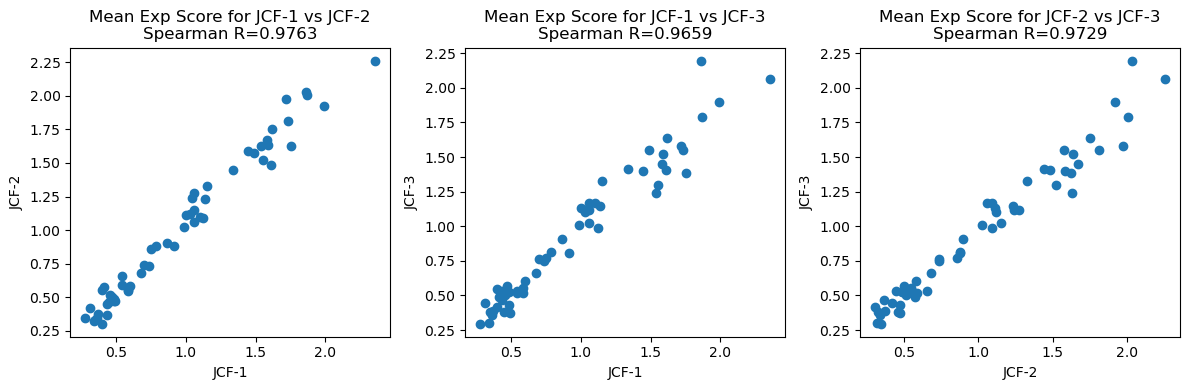

In [109]:
from itertools import combinations
from scipy.stats import spearmanr

dff = adata.obs[['sample']].join(exp_all).groupby('sample', observed=True).mean().T
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sample_pairs = list(combinations(dff.columns.unique().tolist(), 2))

for ax, (x_sample, y_sample) in zip(axes, sample_pairs):
    x = dff[x_sample]
    y = dff[y_sample]
    
    # Compute Pearson correlation
    # use spearman R here because we do not assumen normal distribution of enhancer expression
    corr, _ = spearmanr(x, y)
    
    ax.scatter(x, y)
    ax.set_xlabel(x_sample)
    ax.set_ylabel(y_sample)
    ax.set_title(f'Mean Exp Score for {x_sample} vs {y_sample}\nSpearman R={corr:.4f}')

plt.tight_layout()
#plt.savefig('../6-grammar_final/figs/fig30a_qc_mean.svg', format="svg")
plt.show()

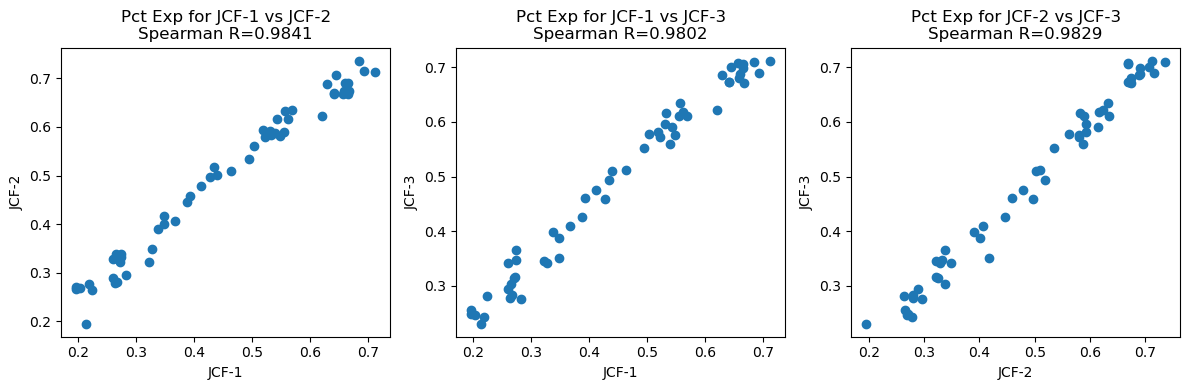

In [110]:
dff = adata.obs[['sample']].join(exp_all).groupby('sample', observed=True).apply(lambda g: (g > 0).sum() / g.notna().sum()).T
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sample_pairs = list(combinations(dff.columns.unique().tolist(), 2))

for ax, (x_sample, y_sample) in zip(axes, sample_pairs):
    x = dff[x_sample]
    y = dff[y_sample]
    
    # Compute Pearson correlation
    # use spearman R here because we do not assumen normal distribution of enhancer expression
    corr, _ = spearmanr(x, y)
    
    ax.scatter(x, y)
    ax.set_xlabel(x_sample)
    ax.set_ylabel(y_sample)
    ax.set_title(f'Pct Exp for {x_sample} vs {y_sample}\nSpearman R={corr:.4f}')

plt.tight_layout()
#plt.savefig('../6-grammar_final/figs/fig30b_qc_pct.svg', format="svg")
plt.show()

# Setting up exp threshold

In the reporter assay, the promoter alone is able to drive some baseline expression. We'd like to determine a cutoff to eliminate that baseline expression.

Given microscopy data, we know three inert sequences that did not drive expression. We would use those to set up the baseline cutoff.

In [111]:
flattened = exp_all[['ORL30', 'ORL31', 'ORL32']].values.flatten()
inert = flattened[~np.isnan(flattened)]

In [112]:
# Use 95% as cutoff
cutoff = np.percentile(inert, 95)
cutoff

2.280427335016228

Now given the cutoff, I would mask any expression score below this cutoff as 0.

In [113]:
exp_all = exp_all.where((exp_all.isna()) | (exp_all > cutoff), 0)

# Merging with mRNA Data

In [114]:
# convert exp_all matrix to an annData object
edata = ad.AnnData(exp_all)

In [115]:
edata.raw = edata.copy()

In [116]:
del adata.varm

In [117]:
# merge the edata (enhancer expression) with adata (mRNA expression)
mdata = ad.concat([adata, edata], axis=1, join="outer", merge="first")

In [118]:
mdata

AnnData object with n_obs × n_vars = 16929 × 15006
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res3', 'celltype', 'updated_label', 'col_celltype', 'cellBC'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'KH', 'Unique name (used in some papers)', 'Human homolog', 'Gene Name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

# Visualization tested enhancers by dotplot

In [119]:
exp_all = exp_all.merge(adata.obs[['col_celltype']], left_index = True, right_index = True, how = 'left')

In [120]:
dot_color = exp_all.groupby('col_celltype', observed=True).mean()
dot_color = dot_color.fillna(0)
dot_size = exp_all.groupby('col_celltype', observed=True).apply(lambda g: (g > 0).sum() / g.notna().sum())

In [123]:
# make the dict for enhancers
selected_enhancers = lookup[['bin-anno', 'enhancer_id']].drop_duplicates()
test_bin2eh = selected_enhancers.groupby('bin-anno').agg(list).to_dict()['enhancer_id']
test_bin2eh = {k: test_bin2eh[k] for k in ['Inert', 'Moderate', 'Robust']}

# Test Enhancers Plot

In [124]:
# Ready to plot
dotplot = sc.pl.dotplot(
    mdata,
    categories_order = ['b6.5','a6.5', 'a6.7 PSV','a6.7 ASV','Trunk Lateral Cell', 'Endoderm (A)','Primary Notochord',
                        'VNC + PSV','A-line ASV/PSV','LNC', 'Endoderm (B)','Secondary Notochord','Mesenchyme',
                        'Epidermis (a)','Epidermis (b)', 'Heart', 'Muscle A/B', 'Germ Cell'],
    groupby='col_celltype',
    var_names=test_bin2eh,
    return_fig = True,
    cmap = 'Greens',
    dot_max = 0.6
)

In [125]:
# Use custom dotcolor and dotsize, as the original dotplot function does not know how to deal with NA value
dotplot.dot_color_df = dot_color.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]
dotplot.dot_size_df = dot_size.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]

In [126]:
# Set up min dot threshold
dot_min = 0.15

In [127]:
dotplot.dot_size_df = dotplot.dot_size_df.where(dotplot.dot_size_df>dot_min, 0)

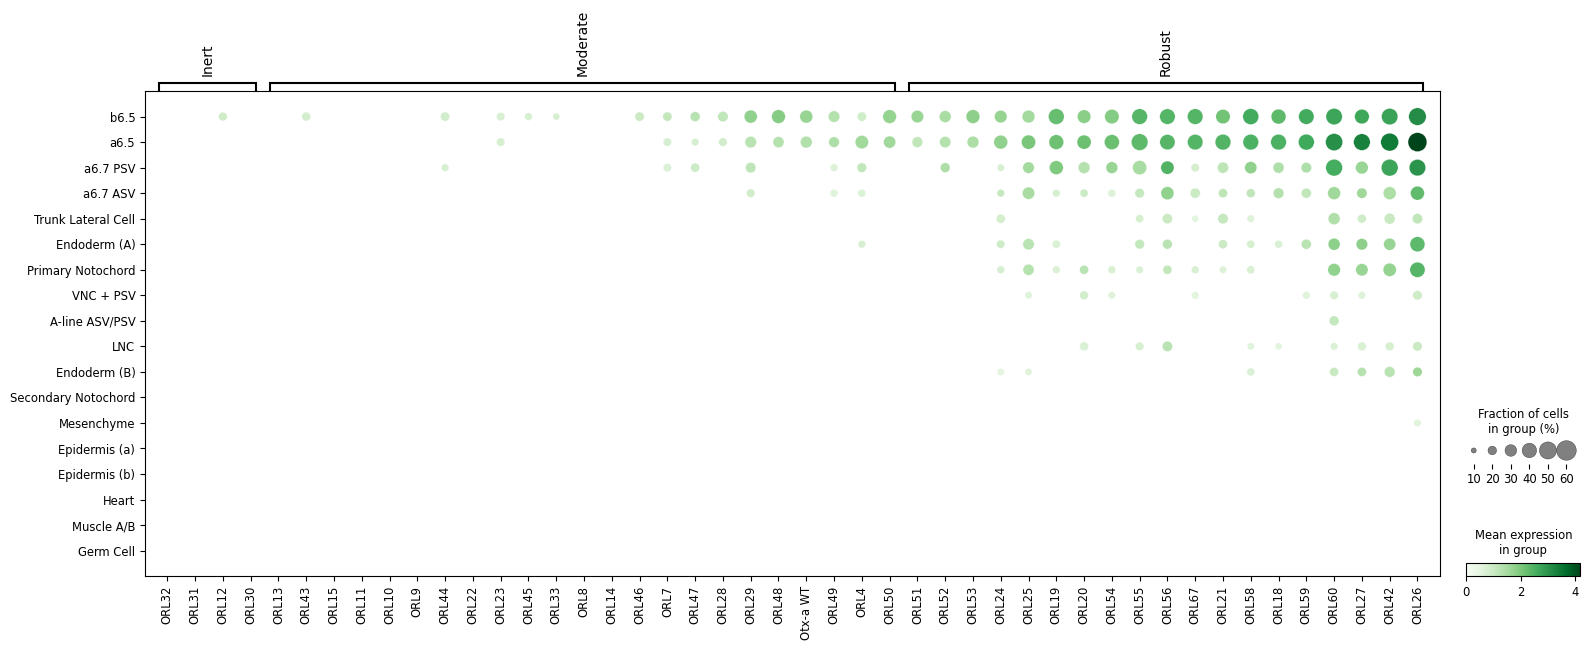

In [128]:
# make main figure 5
dotplot.dot_edge_color = 'white'
dotplot.show()
#dotplot.savefig('../6-grammar_final/figs/everything_in_one_enhancer_dotplot.svg', format="svg")